In [28]:
import sys;

print(sys.version);
print(sys.version_info  )

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
sys.version_info(major=3, minor=13, micro=15, releaselevel='final', serial=0)


pandas==3.0.6
matplotlib==3.11.2
seaborn==0.13.2
scikit-learn==1.9.1

In [29]:
%pip install -r /content/bibliothheque.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: '/content/bibliothheque.txt'


In [30]:
import matplotlib.pyplot as plt # c
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [31]:
import sys;
print(sys.version);
print(sys.version_info);

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
sys.version_info(major=3, minor=13, micro=15, releaselevel='final', serial=0)


Que prépare ce code ?

L'appel fetch_openml stocke les colonnes d'entrée dans X_raw.

…
Les listes de fonctionnalités séparent les variables numériques des variables catégorielles.

L'appel copy() crée X avec seulement les cinq colonnes sélectionnées.

In [32]:
from sklearn.datasets import fetch_openml

# Charger les données brutes et convertir la cible en entiers.

"""
plus en detail
Elle a chargé le jeu de données Titanic,
converti la variable cible y en entiers et
créé les variables X_raw, X, numeric_features,
categorical_features et selected_features comme prévu.
"""
X_raw, y = fetch_openml(
    "titanic",
    version=1,
    as_frame=True,
    return_X_y=True,
)
y = y.astype(int)

numeric_features = ["age", "fare"]
categorical_features = ["embarked", "sex", "pclass"]
selected_features = numeric_features + categorical_features
X = X_raw[selected_features].copy()

L'appel X.head() affiche les cinq premières lignes des variables sélectionnées.

L'appel X.isna().sum() compte les valeurs manquantes dans chaque colonne sélectionnée.

L'appel X_raw.duplicated().sum() compte les lignes entièrement dupliquées dans l'ensemble de données brutes.

In [33]:
from sklearn.datasets import fetch_openml

X_raw, y = fetch_openml(
    "titanic",
    version=1,
    as_frame=True,
    return_X_y=True,
)
y = y.astype(int)

numeric_features = ["age", "fare"]
categorical_features = ["embarked", "sex", "pclass"]
selected_features = numeric_features + categorical_features
X = X_raw[selected_features].copy()

# Auditer avant toute modification.
print("Aperçu des données :")
print(X.head())
print("\nValeurs manquantes :")
print(X.isna().sum())
print("\nDoublons complets dans le jeu brut :")
print(X_raw.duplicated().sum())

Aperçu des données :
       age      fare embarked     sex  pclass
0  29.0000  211.3375        S  female       1
1   0.9167  151.5500        S    male       1
2   2.0000  151.5500        S  female       1
3  30.0000  151.5500        S    male       1
4  25.0000  151.5500        S  female       1

Valeurs manquantes :
age         263
fare          1
embarked      2
sex           0
pclass        0
dtype: int64

Doublons complets dans le jeu brut :
0


Nettoyer les données et visualiser les distributions

Nettoyer une copie pour l’exploration

Avec pandas, la médiane fournit une valeur centrale pour les colonnes numériques. Le mode fournit la valeur la plus fréquente pour le port d’embarquement.

La ligne data_clean = X.copy() crée la copie réservée à l’exploration.



Les colonnes age et fare utilisent leur médiane respective comme valeur de remplacement.



La colonne embarked utilise son mode comme valeur de remplacement.



La colonne survived associe chaque passager à son étiquette de survie.



Le contrôle avec isna().sum() compte les valeurs encore absentes dans chaque colonne.

In [34]:
# Préparer une copie nettoyée uniquement pour l'exploration.


data_clean = X.copy()
data_clean["age"] = data_clean["age"].fillna(data_clean["age"].median())
data_clean["fare"] = data_clean["fare"].fillna(data_clean["fare"].median())
data_clean["embarked"] = data_clean["embarked"].fillna(
    data_clean["embarked"].mode().iloc[0]
)
data_clean["survived"] = y

print("\nValeurs manquantes après nettoyage exploratoire :")
print(data_clean.isna().sum())


Valeurs manquantes après nettoyage exploratoire :
age         0
fare        0
embarked    0
sex         0
pclass      0
survived    0
dtype: int64


Tracer les distributions de classe et d’âge

Le premier graphique de seaborn compare les effectifs de chaque classe selon la survie. Le second utilise Matplotlib pour afficher une distribution empilée des âges.

Comment les graphiques sont construits





Chaque appel à plt.subplots(figsize=(7, 4)) prépare une figure avec son axe.



Le countplot compte les passagers dans chaque valeur de pclass.



La couleur définie par survived sépare les deux résultats de survie.



Le histplot répartit les âges sur l’axe horizontal.



La valeur multiple="stack" empile les groupes de survie dans chaque intervalle d’âge.

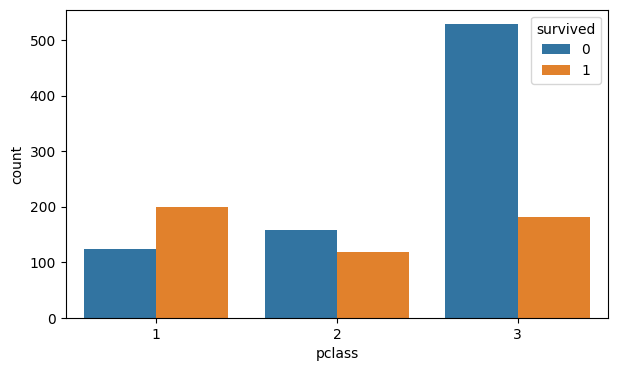

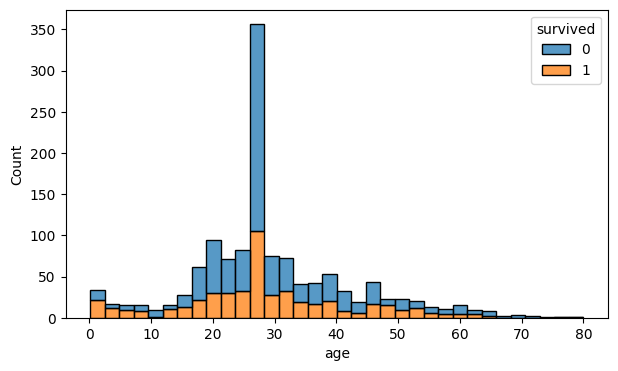

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualiser les classes et la distribution des âges.
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=data_clean, x="pclass", hue="survived", ax=ax)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(
    data=data_clean,
    x="age",
    hue="survived",
    multiple="stack",
    ax=ax,
)
plt.show()

Séparer les données brutes

La séparation entraînement-test réserve une partie des données pour l’évaluation finale. Cette frontière empêche les informations du jeu de test d’influencer l’entraînement.

Que fait cette séparation ?





La fonction train_test_split() crée les ensembles d’entraînement et de test à partir de X ainsi que de y.



Le paramètre test_size=0.2 réserve 20 % des lignes pour le test.



Le paramètre random_state=0 rend la séparation reproductible.



Le paramètre stratify=y conserve la répartition des classes de survie.



La variable X reste brute. La copie data_clean ne participe pas à cette séparation.

In [36]:
from sklearn.model_selection import train_test_split

# Séparer les données brutes avant tout prétraitement prédictif.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y,
)

In [37]:
from sklearn.linear_model import LogisticRegression

# Obstacle volontaire : le modèle naïf reçoit encore textes et valeurs manquantes.
try:
    naive_model = LogisticRegression()
    naive_model.fit(X_train, y_train)
except (ValueError, TypeError) as error:
    print("\nÉchec attendu du modèle naïf :", type(error).__name__)


Échec attendu du modèle naïf : ValueError


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Construire les deux branches de prétraitement.
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression()),
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


print("\nRapport de classification :")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-survie", "Survie"],
    )
)



Rapport de classification :
              precision    recall  f1-score   support

  Non-survie       0.82      0.86      0.84       162
      Survie       0.75      0.69      0.72       100

    accuracy                           0.79       262
   macro avg       0.78      0.77      0.78       262
weighted avg       0.79      0.79      0.79       262



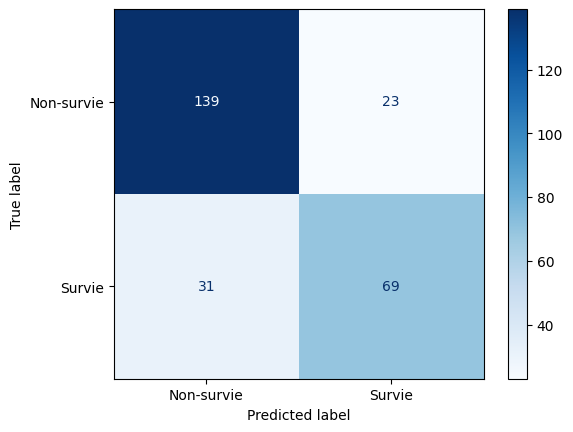

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Non-survie", "Survie"],
    cmap="Blues",
)
plt.show()

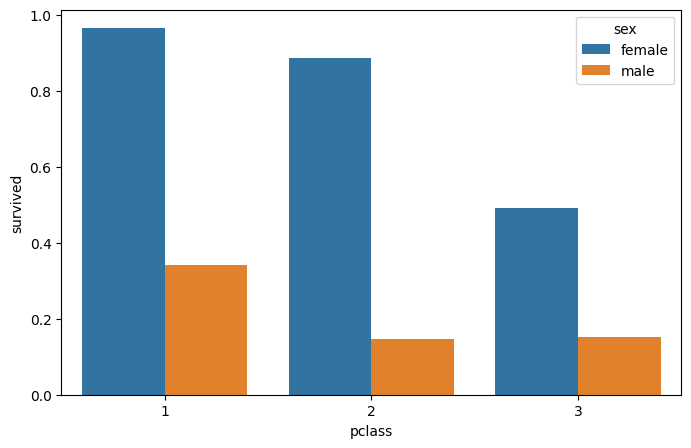

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=data_clean,
    x="pclass",
    y="survived",
    hue="sex",
    errorbar=None,
    ax=ax,
)
plt.show()